In [1]:

import edhec_risk_kit as erk

ind = erk.get_ind_returns()
er = erk.annualize_rets(ind['1995':'2000'], 12)
cov = ind['1995':'2000'].cov()

C:\Users\delni\edhec_risk_kit.py:46: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('ind30_m_vw_rets.csv', header = 0, index_col= 0, parse_dates= True)/100


In [2]:
from scipy.optimize import minimize 

<Axes: xlabel='Vol'>

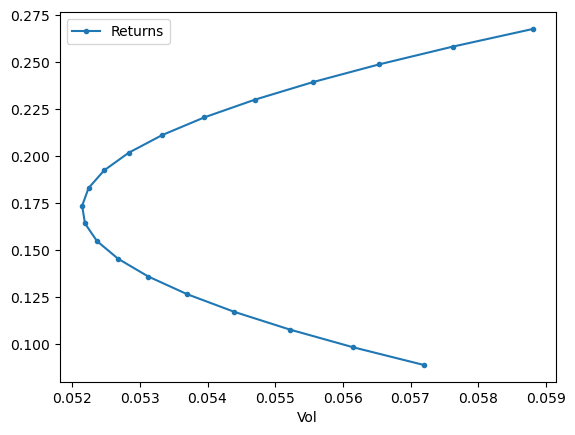

In [3]:
l = ['Games', 'Fin']
erk.plot_ef2(20, er[l], cov.loc[l,l])

In [4]:
import numpy as np
def minimize_vol(target_return, er, cov):
    """
    target_ret -> W
    """
    n= er.shape[0]
    init_guess = np.repeat(1/n, n)
    bounds = ((0.0, 1.0),)*n
    return_is_target = {
        'type':'eq', 
        'args':(er,),
        'fun': lambda weights, er: target_return - erk.portfolio_return(weights, er)
    }
    weights_sum_to_1 = {
        'type' : 'eq',
        'fun': lambda weights: np.sum(weights)-1
    }
    results = minimize(erk.portfolio_vol, init_guess,
                       args=(cov,), method = "SLSQP",
                       options = {'disp': False},
                       constraints = (return_is_target, weights_sum_to_1),
                       bounds = bounds
                      )
    return results.x
    

In [5]:
l

['Games', 'Fin']

In [6]:
w15 = erk.minimize_vol(0.15, er[l], cov.loc[l,l])
vol15 = erk.portfolio_vol(w15, cov.loc[l,l])
vol15

np.float64(0.05250418123905939)

In [7]:
w15

array([0.65749081, 0.34250919])

In [8]:
import pandas as pd
def optimal_weights(n_points, er, cov):
    """
    ->list of weights
    """
    target_rs = np.linspace(er.min(), er.max(), n_points)
    weights = [minimize_vol(target_return, er, cov) for target_return in target_rs]
    return weights
    
def plot_ef(n_points, er, cov):
    """
    plots EF 2 asset
    """
    weights = optimal_weights(n_points, er, cov)
    rets = [erk.portfolio_return(w, er) for w in weights]
    vols = [erk.portfolio_vol(w, cov) for w in weights]
    ef = pd.DataFrame({'Returns': rets, 'Vol': vols})
    return ef.plot.line(x = 'Vol', y = 'Returns', style = '.-')

<Axes: xlabel='Vol'>

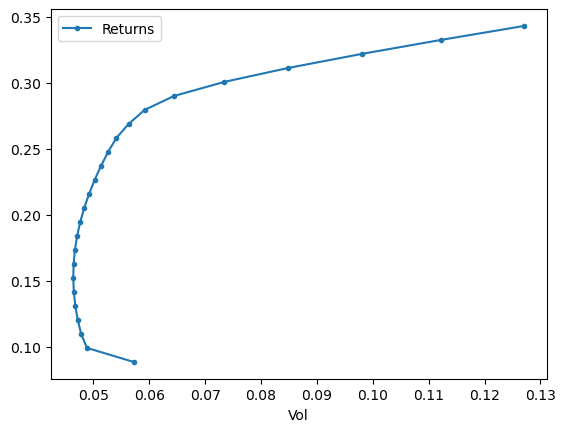

In [9]:
l = ['Smoke', 'Fin', 'Games', 'Coal']
plot_ef(25, er[l], cov.loc[l,l])

<Axes: xlabel='Vol'>

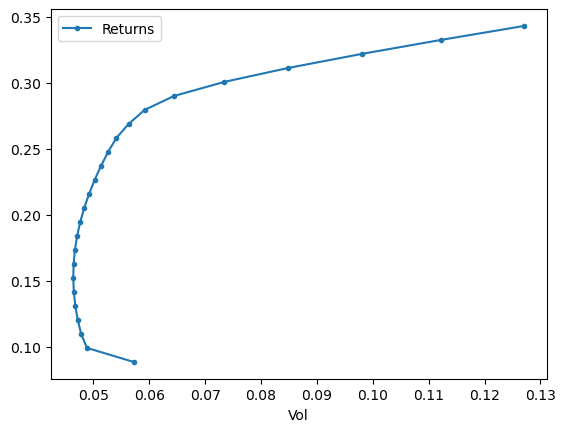

In [11]:
l = ['Smoke', 'Fin', 'Games', 'Coal']
erk.plot_ef(25, er[l], cov.loc[l,l])